# 00 — Data Audit

Explore the Cattle Breed dataset before training:
- Class distribution
- Sample images per breed
- Image size / resolution stats
- Corrupt image check
- Run stratified split and generate manifests

In [1]:
import sys, os
from pathlib import Path

# Auto-detect project root
PROJECT_ROOT = Path(os.getcwd()).resolve()
if 'notebooks' in str(PROJECT_ROOT):
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/ajitkumarsingh/Desktop/desktop/cattle-breed-classifier-webapp


In [3]:
!pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.1 MB/s eta 0:00:00a 0:00:01


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 1. Dataset Overview

In [5]:
DATA_DIR = PROJECT_ROOT / 'Cattle_Resized'

class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
print(f'Number of classes: {len(class_dirs)}')
print(f'Class names:')
for d in class_dirs:
    count = len(list(d.glob('*')))
    print(f'  {d.name}: {count} images')

Number of classes: 27
Class names:
  .DS_Store: 0 images
  Alambadi Cow: 93 images
  Amritmahal Cow: 95 images
  Banni Buffalo: 36 images
  Bargur Cow: 60 images
  Dangi Cow: 84 images
  Deoni Cow: 103 images
  Gir Cow: 250 images
  Hallikar Cow: 186 images
  Jaffrabadi Buffalo: 102 images
  Kangayam Cow: 116 images
  Kankrej Cow: 178 images
  Kasaragod Cow: 95 images
  Kenkatha Cow: 56 images
  Kherigarh Cow: 36 images
  Malnad gidda Cow: 107 images
  Mehsana Buffalo: 96 images
  Nagori Cow: 89 images
  Nagpuri Buffalo: 220 images
  Nili ravi Buffalo: 92 images
  Nimari Cow: 87 images
  Pulikulam Cow: 127 images
  Rathi Cow: 148 images
  Sahiwal Cow: 240 images
  Shurti Buffalo: 60 images
  Tharparkar Cow: 221 images
  Umblachery Cow: 79 images


## 2. Class Distribution

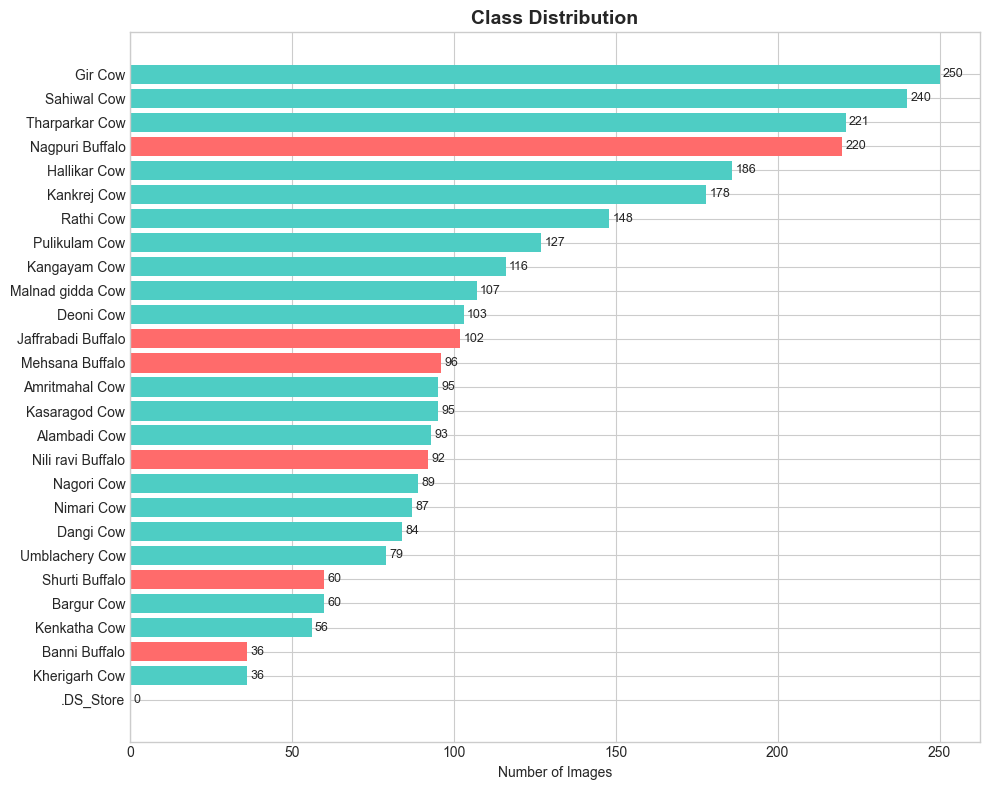


Total images: 3056
Min class size: 0
Max class size: 250
Mean class size: 113.2


In [6]:
class_counts = {}
for d in class_dirs:
    class_counts[d.name] = len([f for f in d.iterdir() if f.is_file()])

df_counts = pd.DataFrame([
    {'breed': k, 'count': v} for k, v in class_counts.items()
]).sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#FF6B6B' if 'Buffalo' in b else '#4ECDC4' for b in df_counts['breed']]
ax.barh(df_counts['breed'], df_counts['count'], color=colors)
ax.set_xlabel('Number of Images')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')

# Add count labels
for i, (_, row) in enumerate(df_counts.iterrows()):
    ax.text(row['count'] + 1, i, str(row['count']), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'ml' / 'artifacts' / 'figures' / 'class_distribution.png'), dpi=150)
plt.show()

print(f'\nTotal images: {sum(class_counts.values())}')
print(f'Min class size: {min(class_counts.values())}')
print(f'Max class size: {max(class_counts.values())}')
print(f'Mean class size: {np.mean(list(class_counts.values())):.1f}')

## 3. Sample Images per Breed

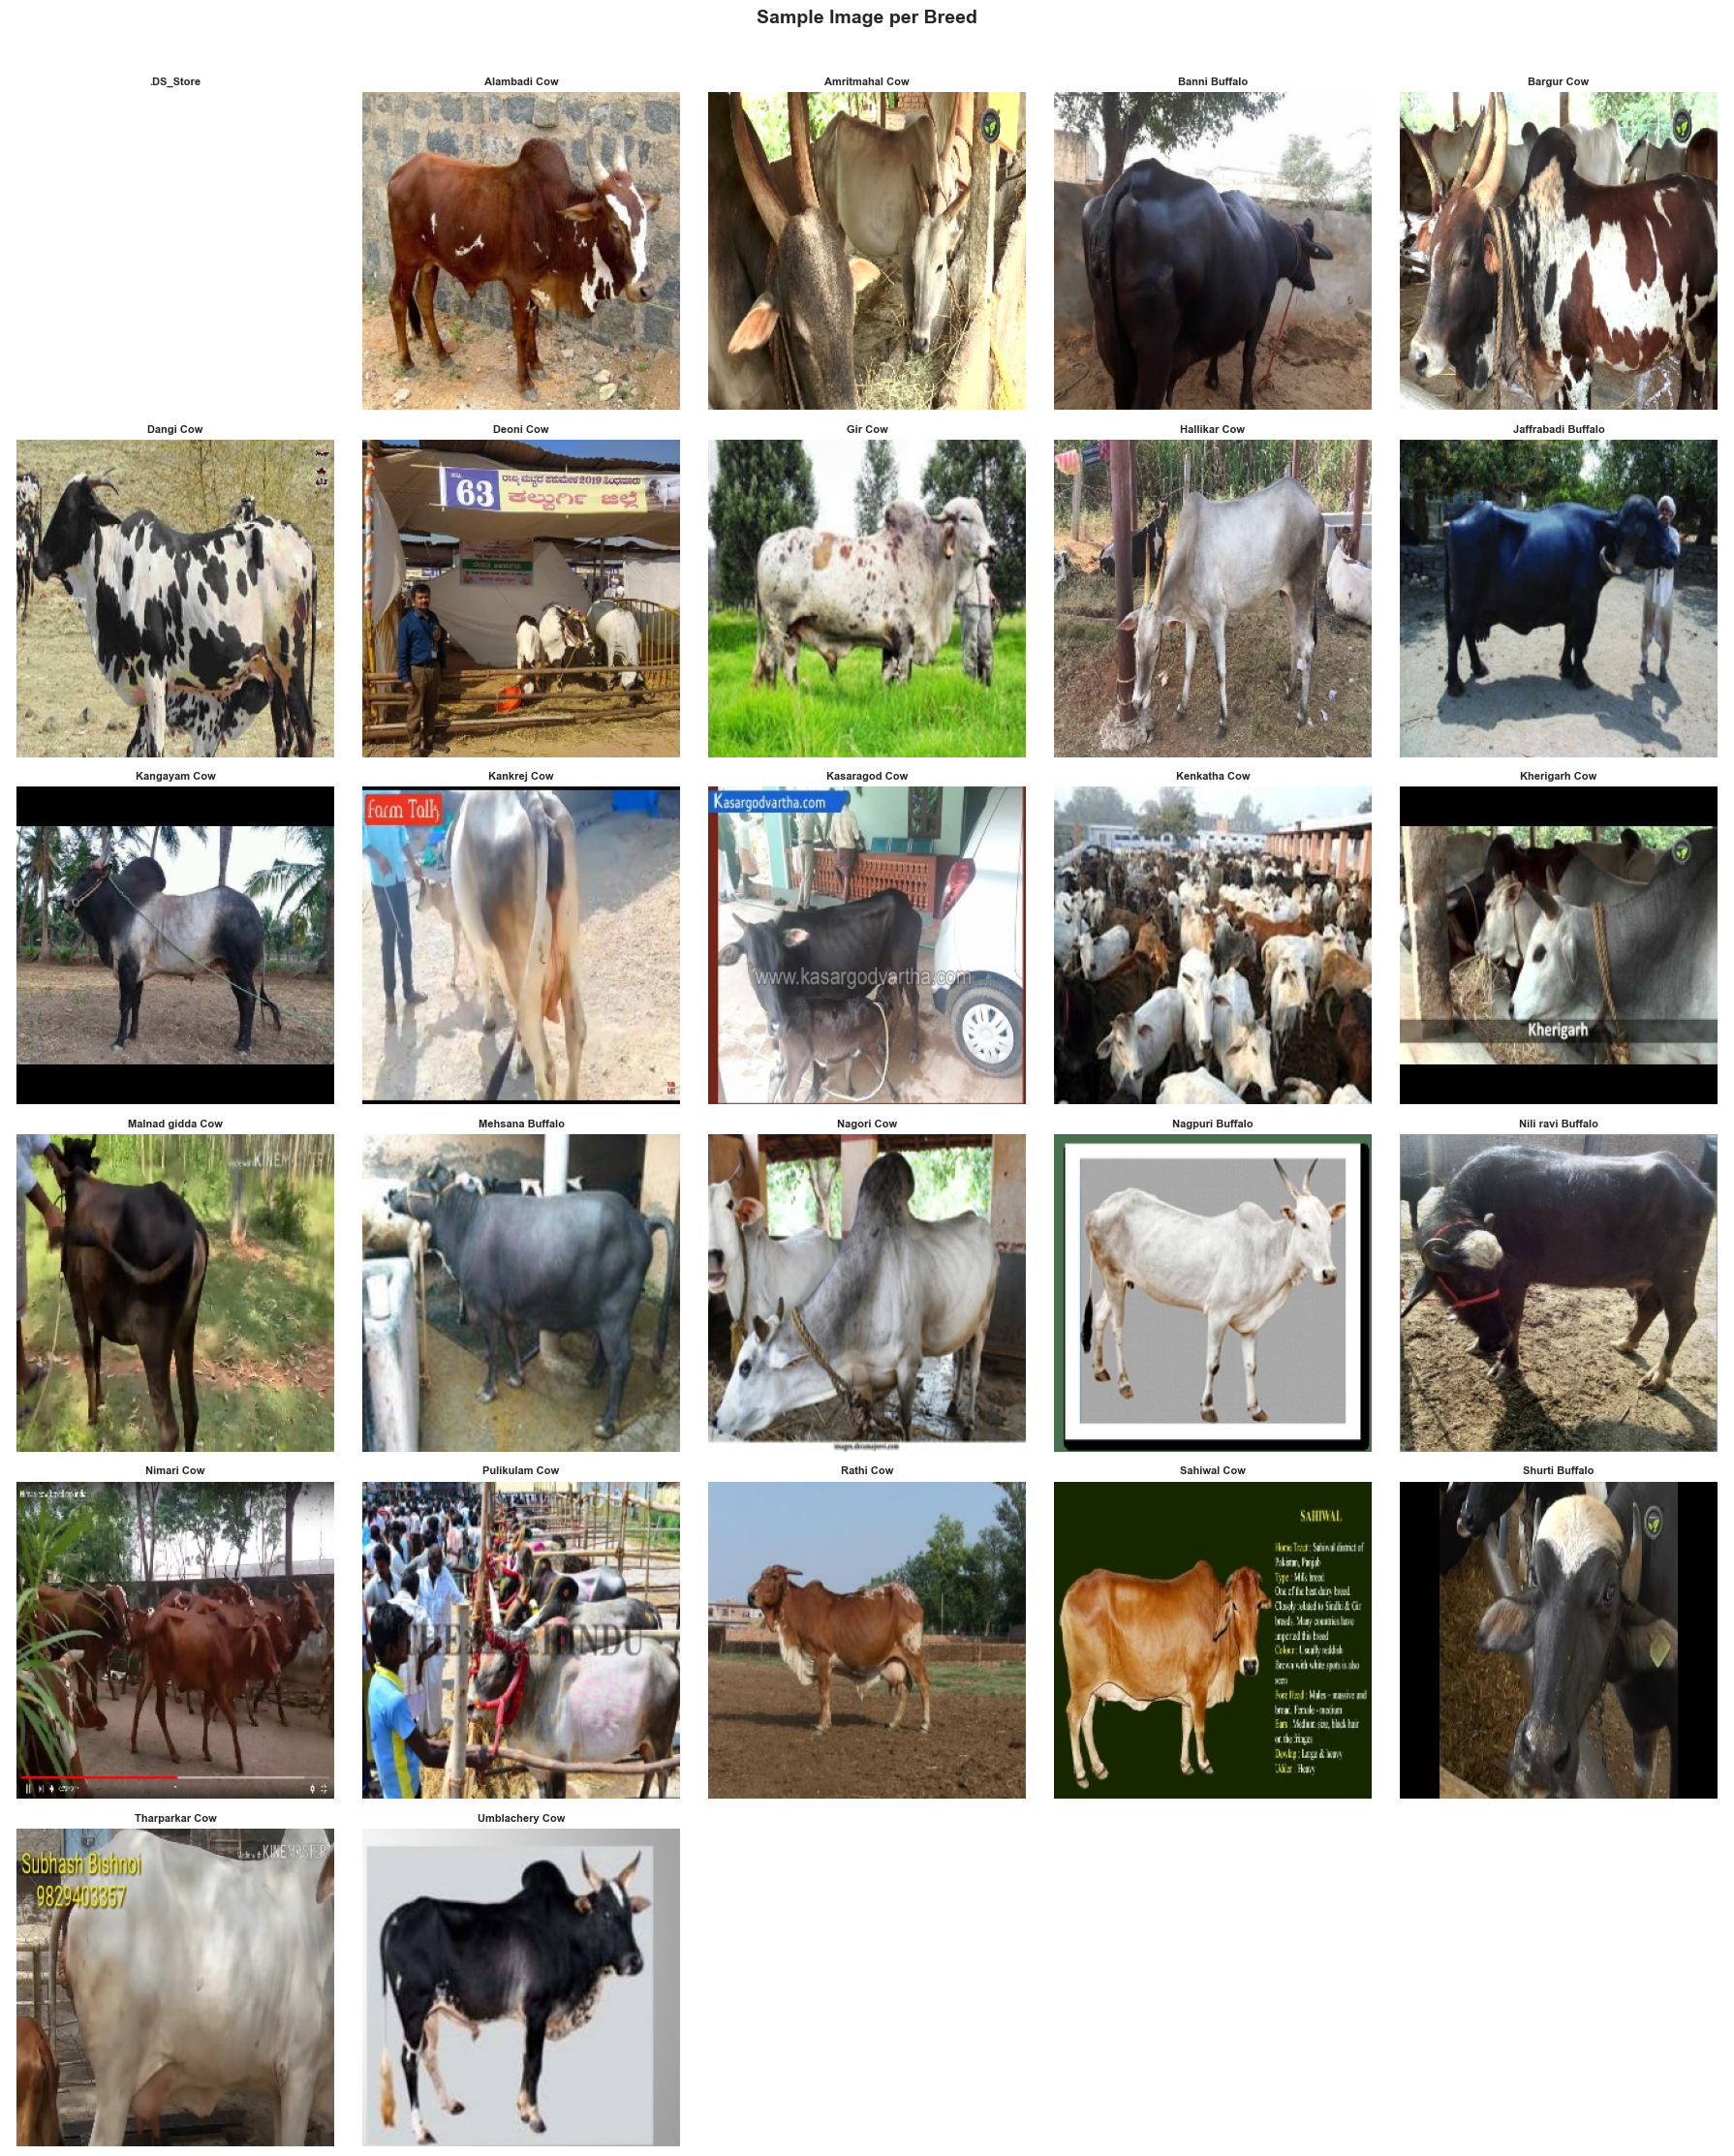

In [7]:
fig, axes = plt.subplots(6, 5, figsize=(18, 22))
axes = axes.flatten()

for idx, class_dir in enumerate(class_dirs[:30]):
    if idx >= len(axes):
        break
    images = sorted(class_dir.glob('*'))[:1]
    if images:
        img = Image.open(images[0]).convert('RGB')
        axes[idx].imshow(img)
    axes[idx].set_title(class_dir.name, fontsize=8, fontweight='bold')
    axes[idx].axis('off')

# Hide unused axes
for idx in range(len(class_dirs), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Image per Breed', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'ml' / 'artifacts' / 'figures' / 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Image Size Statistics

Total valid images: 3056
Width  — min: 256, max: 256, mean: 256
Height — min: 256, max: 256, mean: 256
Size   — min: 1.6KB, max: 60.3KB, mean: 32.1KB


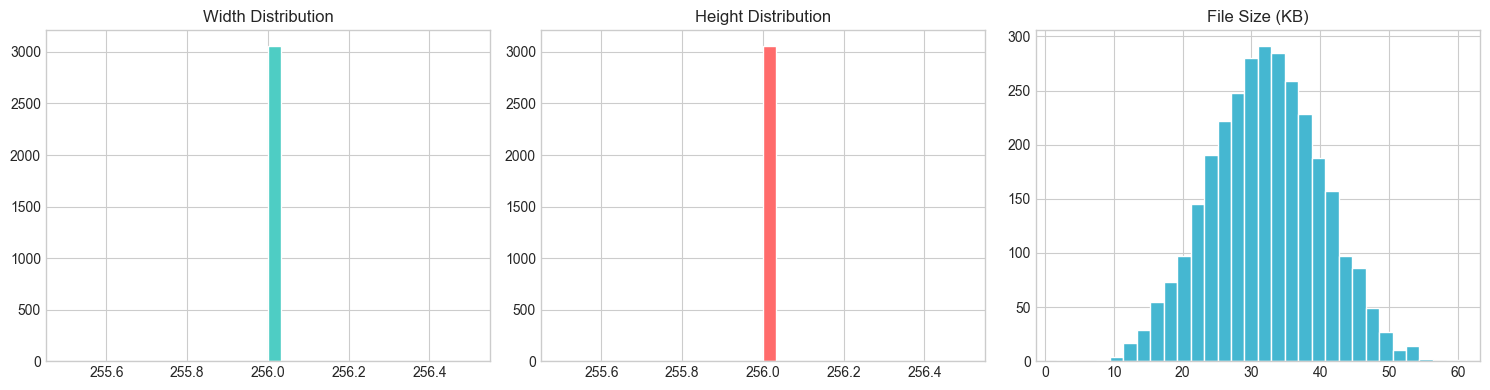

In [8]:
widths, heights, sizes_kb = [], [], []

for class_dir in class_dirs:
    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp'}:
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
                    sizes_kb.append(img_path.stat().st_size / 1024)
            except Exception:
                pass

print(f'Total valid images: {len(widths)}')
print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')
print(f'Size   — min: {min(sizes_kb):.1f}KB, max: {max(sizes_kb):.1f}KB, mean: {np.mean(sizes_kb):.1f}KB')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths, bins=30, color='#4ECDC4', edgecolor='white')
axes[0].set_title('Width Distribution')
axes[1].hist(heights, bins=30, color='#FF6B6B', edgecolor='white')
axes[1].set_title('Height Distribution')
axes[2].hist(sizes_kb, bins=30, color='#45B7D1', edgecolor='white')
axes[2].set_title('File Size (KB)')
plt.tight_layout()
plt.show()

## 5. Validate & Split Dataset

In [9]:
from ml.src.data.prepare_dataset import validate_images, stratified_split, \
    generate_class_balance_report, save_manifest
from ml.src.utils.io import ensure_dirs

# Create output directories
manifests_dir = PROJECT_ROOT / 'ml' / 'artifacts' / 'manifests'
reports_dir = PROJECT_ROOT / 'ml' / 'artifacts' / 'reports'
figures_dir = PROJECT_ROOT / 'ml' / 'artifacts' / 'figures'
ensure_dirs(manifests_dir, reports_dir, figures_dir)

# Validate
valid_records, corrupt_records = validate_images(DATA_DIR)
print(f'Valid: {len(valid_records)}, Corrupt: {len(corrupt_records)}')

if corrupt_records:
    print('\nCorrupt files:')
    for r in corrupt_records:
        print(f"  {r['image_path']}: {r['error']}")


Validation complete: 3056 valid, 0 corrupt
Valid: 3056, Corrupt: 0


In [10]:
# Stratified split
train, val, test = stratified_split(valid_records, 0.70, 0.15, 0.15, random_seed=42)

for r in train: r['split'] = 'train'
for r in val: r['split'] = 'val'
for r in test: r['split'] = 'test'

# Save manifests
save_manifest(train, manifests_dir / 'train.csv')
save_manifest(val, manifests_dir / 'val.csv')
save_manifest(test, manifests_dir / 'test.csv')
save_manifest(train + val + test, manifests_dir / 'all.csv')

# Report
report = generate_class_balance_report(train, val, test)
for split in ['train', 'val', 'test']:
    info = report[split]
    print(f"{split:>5}: {info['total']:>5} images | "
          f"min={info['min_samples']} max={info['max_samples']} "
          f"mean={info['mean_samples']}")

  Saved 2139 records to /Users/ajitkumarsingh/Desktop/desktop/cattle-breed-classifier-webapp/ml/artifacts/manifests/train.csv
  Saved 458 records to /Users/ajitkumarsingh/Desktop/desktop/cattle-breed-classifier-webapp/ml/artifacts/manifests/val.csv
  Saved 459 records to /Users/ajitkumarsingh/Desktop/desktop/cattle-breed-classifier-webapp/ml/artifacts/manifests/test.csv
  Saved 3056 records to /Users/ajitkumarsingh/Desktop/desktop/cattle-breed-classifier-webapp/ml/artifacts/manifests/all.csv
train:  2139 images | min=25 max=175 mean=82.3
  val:   458 images | min=6 max=37 mean=17.6
 test:   459 images | min=5 max=38 mean=17.7


## 6. Breed Metadata Preview

In [11]:
from ml.src.data.breed_metadata import BreedMetadataStore

store = BreedMetadataStore()
print(f'Loaded metadata for {store.num_breeds} breeds\n')

df_meta = pd.DataFrame(store.get_all())
df_meta[['breed_name', 'animal_type', 'region', 'primary_use', 'avg_milk_liters_per_day']]

Loaded metadata for 26 breeds



,breed_name,animal_type,region,primary_use,avg_milk_liters_per_day
0,Alambadi Cow,Cow,"Tamil Nadu, India",Draught,2-3
1,Amritmahal Cow,Cow,"Karnataka, India",Draught,1-2
2,Banni Buffalo,Buffalo,"Gujarat, India",Dairy,10-14
3,Bargur Cow,Cow,"Tamil Nadu, India",Draught,2-3
4,Dangi Cow,Cow,"Maharashtra, India",Dual Purpose,1-3
5,Deoni Cow,Cow,"Maharashtra / Karnataka, India",Dual Purpose,3-5
6,Gir Cow,Cow,"Gujarat, India",Dairy,6-10
7,Hallikar Cow,Cow,"Karnataka, India",Draught,1-2
8,Jaffrabadi Buffalo,Buffalo,"Gujarat, India",Dairy,8-12
9,Kangayam Cow,Cow,"Tamil Nadu, India",Draught,2-4


---
**✅ Data audit complete.** Manifests saved to `ml/artifacts/manifests/`. Proceed to training notebooks.